In [ ]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, AnyMessage, ToolMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

In [19]:
from google.colab import userdata
api_key = userdata.get('GROQ_API_KEY1')

In [20]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key,
    verbose=True,
    # other params...
)

In [21]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [22]:
def chat_node(state : ChatState):

  decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
  print(decision)
  if decision['approved'] == "no":
    return {'messages' : AIMessage(content = "human not approved")}
  else :
    ans = llm.invoke(state['messages'])
    return {'messages' : ans}

In [23]:
graph = StateGraph(ChatState)

graph.add_node("chat", chat_node)
graph.add_edge(START, "chat")
graph.add_edge("chat", END)
checkpointer = MemorySaver()
chatbot = graph.compile(checkpointer=checkpointer)

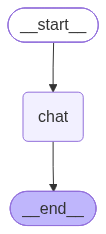

In [24]:
chatbot

In [31]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        HumanMessage(content = "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = chatbot.invoke(initial_input, config=config)

In [ ]:
result

In [33]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [34]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")


Backend message - {'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'} 
 Approve this question? (y/n): no


In [35]:
# Resume the graph with the approval decision
final_result = chatbot.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

{'approved': 'no'}


In [39]:
print(final_result['messages'][-3].content)

**Gradient descent in a nutshell**

Imagine you’re standing on a foggy hill and you want to find the very bottom (the lowest point).  
You can’t see the whole landscape, but you can feel the slope right where you’re standing.

1. **Feel the slope** – At your current spot you check which direction goes downhill the fastest.  
   In math this “slope” is called the **gradient** (it tells you the direction of steepest ascent; we go the opposite way).

2. **Take a step downhill** – You move a little bit in the opposite direction of the gradient.  
   How big a step you take is the **learning rate** (sometimes called step‑size). Too big → you might jump over the bottom; too small → it takes forever.

3. **Repeat** – After the step you feel the new slope, step again, and keep doing this over and over.

When the slope becomes (almost) flat, you’re near the bottom. That point is a **minimum** of the function you’re trying to minimize.

---

### How it looks in a simple picture

```
   ^
   |   